In [137]:
import pandas as pd
import numpy as np

In [138]:
df=pd.read_csv("Salary_Data.csv")

In [139]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [140]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [142]:
# check for linearity

In [143]:
import matplotlib.pyplot as plt

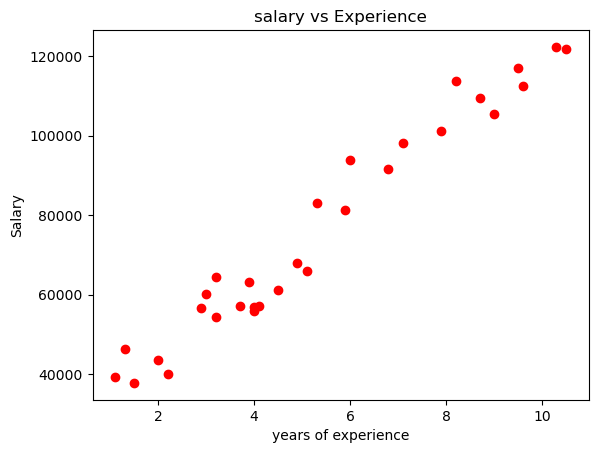

In [144]:
plt.title('salary vs Experience')
plt.xlabel('years of experience')
plt.ylabel('Salary')
plt.scatter(df['YearsExperience'],df['Salary'],color='red')

In [145]:
x=df[['YearsExperience']]
y=df[['Salary']]

In [146]:
x;

In [147]:
y;

In [148]:
# cross validation

In [149]:
from sklearn.model_selection import train_test_split

In [150]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [151]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((22, 1), (22, 1), (8, 1), (8, 1))

In [152]:
x_train

,YearsExperience
17,5.3
22,7.9
5,2.9
16,5.1
8,3.2
14,4.5
23,8.2
20,6.8
1,1.3
29,10.5


In [153]:
x_test

,YearsExperience
2,1.5
28,10.3
13,4.1
10,3.9
26,9.5
24,8.7
27,9.6
11,4.0


In [154]:
y_train

,Salary
17,83088.0
22,101302.0
5,56642.0
16,66029.0
8,64445.0
14,61111.0
23,113812.0
20,91738.0
1,46205.0
29,121872.0


In [155]:
y_test

,Salary
2,37731.0
28,122391.0
13,57081.0
10,63218.0
26,116969.0
24,109431.0
27,112635.0
11,55794.0


In [156]:
# build model

In [157]:
from sklearn.linear_model import LinearRegression

In [158]:
lr=LinearRegression()

In [159]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [160]:
# val of m
lr.coef_

array([[9379.71049195]])

In [161]:
# val of c
lr.intercept_

array([26986.69131674])

In [163]:
# compare act and pred

In [164]:
y_pred=lr.predict(x_test)

In [166]:
y_pred = y_pred.ravel()

result = pd.DataFrame({
    'Actual': y_test.values.ravel(),
    'Predicted': y_pred
})

In [167]:
print(result)

     Actual      Predicted
0   37731.0   41056.257055
1  122391.0  123597.709384
2   57081.0   65443.504334
3   63218.0   63567.562235
4  116969.0  116093.940990
5  109431.0  108590.172597
6  112635.0  117031.912039
7   55794.0   64505.533285


In [168]:
y_pred

array([ 41056.25705466, 123597.70938378,  65443.50433372,  63567.56223533,
       116093.94099022, 108590.17259667, 117031.91203942,  64505.53328452])

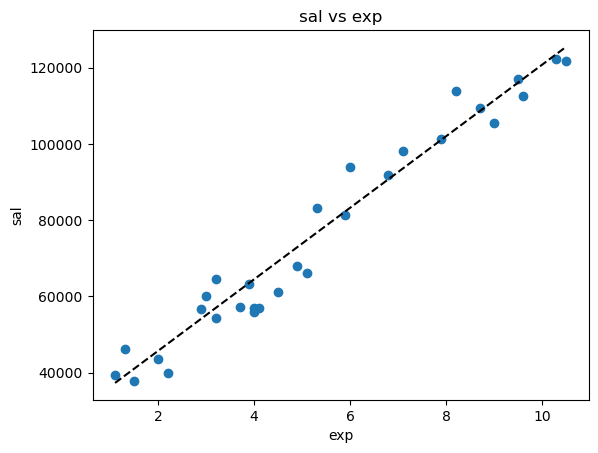

In [169]:
plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df['YearsExperience'], df['Salary']);
plt.plot(x, lr.predict(x), color = 'black', ls = '--');

In [170]:
from sklearn.metrics import mean_absolute_error

In [171]:
mean_absolute_error(y_test,y_pred)

3508.5455930660555

# polynomial reg

In [172]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9779208335417602

In [173]:
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [174]:
# crette polynomial features

In [175]:
from sklearn.preprocessing import PolynomialFeatures

In [176]:
poly=PolynomialFeatures(degree=4)

In [177]:
x_poly=poly.fit_transform(x)

In [178]:
x_poly
# cross val,linear ref model , r2 score

array([[1.00000000e+00, 1.10000000e+00, 1.21000000e+00, 1.33100000e+00,
        1.46410000e+00],
       [1.00000000e+00, 1.30000000e+00, 1.69000000e+00, 2.19700000e+00,
        2.85610000e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01],
       [1.00000000e+00, 2.20000000e+00, 4.84000000e+00, 1.06480000e+01,
        2.34256000e+01],
       [1.00000000e+00, 2.90000000e+00, 8.41000000e+00, 2.43890000e+01,
        7.07281000e+01],
       [1.00000000e+00, 3.00000000e+00, 9.00000000e+00, 2.70000000e+01,
        8.10000000e+01],
       [1.00000000e+00, 3.20000000e+00, 1.02400000e+01, 3.27680000e+01,
        1.04857600e+02],
       [1.00000000e+00, 3.20000000e+00, 1.02400000e+01, 3.27680000e+01,
        1.04857600e+02],
       [1.00000000e+00, 3.70000000e+00, 1.36900000e+01, 5.06530000e+01,
        1.87416100e+02],
       [1.00000000e+00, 3.9000

In [179]:
x_train,x_test,y_train,y_test=train_test_split(x_poly,y,random_state=0)

In [180]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [181]:
y_pred=lr.predict(x_test)

In [182]:
r2_score(y_test,y_pred)

0.9820816859990579